In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
import file_utils
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Nov2025/"

colors = ["darkorange", "crimson", "#2544D0", "olive", "orangered", "#2544D0", "k"]

Lane order statistics: nr, Max, Min, Mean, Std. Dev. : 4.7e-2 1.0 0.9667 0.998 0.00524


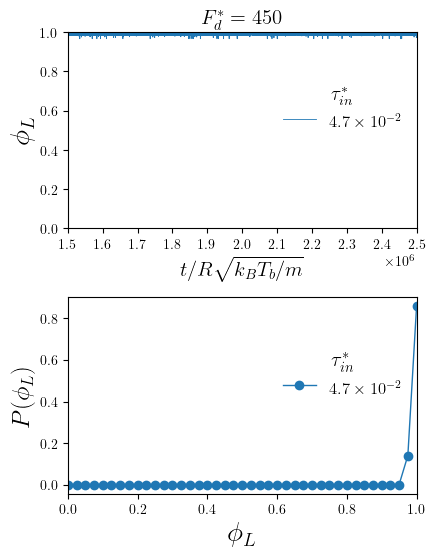

In [9]:
# Last modified : 16.09.25
# ax1 : Plot the lane order parameter as a function of time
# ax2 : Plot the distribution of the order parameter

tau_list = ["4.7e-2"]
color = ["r"]
Fd_list = [450]*len(tau_list)
alp_list = [1]*len(tau_list)

lw = 0.6

# Params for time series
eq_steps = 1e7
frameStart = int(0)
frameEnd = int(2e4)
Nevery = 1
dt = 5e-4

# Params for probability distribution
xmax = 1.0
nBins = 40
binW = (xmax - 0)/nBins

fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (4.5, 6))
plt.ticklabel_format(style = "sci", axis = 'x', scilimits = (0,0))

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Aug_Nov2025", "Fd{fd}".format(fd = Fd_list[i]), "tau_{tau}".format(tau = tau_list[i]), 
                         "laneOrder_steady.dat")
    [[step, order], _] = readData(fpath, 1)

    step = step[frameStart:frameEnd:Nevery]
    order = order[frameStart:frameEnd:Nevery]
    
    # ax1 : time series
    time = [(j-eq_steps)*dt for j in step]
    ax1.plot(time, order, "-", lw = lw, alpha = alp_list[i], label = r"${tau}$".format(tau = float2latex([tau_list[i]])))

    [[step, order], _] = readData(fpath, 1)

    avg_order = sum(order)/len(order)
    var = [(j - avg_order)**2 for j in order]
    var = sum(var)/(len(var) - 1)

    print("Lane order statistics: nr, Max, Min, Mean, Std. Dev. : {nr} {Max} {Min} {avg} {std}".format(nr = tau_list[i],
                                                                                                Max = round(max(order), 4), 
                                                                                                Min = round(min(order), 4), 
                                                                                                avg = round(avg_order, 4), 
                                                                                                std = round(np.sqrt(var), 5)))
    # ax2 : distribution of phi
    phi = np.linspace(0, xmax, nBins + 1)
    Bins = np.zeros(nBins + 1)

    for val in order:
        id = m.floor(val/binW)
        Bins[id] += int(1)

    totalCount = sum(Bins)
    
    for j in range(len(Bins)):
        Bins[j] /= (totalCount)

    ax2.plot(phi, Bins, "o-", lw = 1, label = r"${tau}$".format(tau = float2latex([tau_list[i]])))

ax1.set(xlim = (1.5e6, 2.5e6))
ax1.set_xlabel(r"$t/R\sqrt{k_BT_b/m}$", fontsize = 15)
ax1.set_ylabel(r"$\phi_L$", fontsize = 20)
ax1.set_xticks(np.arange(1.5e6, 2.52e6, 1e5))
ax1.set_yticks(np.arange(0, 1.1, 0.2))

leg = ax1.legend(title = r"$\tau_{in}^*$", fontsize = 12, ncols =1, frameon = False, bbox_to_anchor = (1, 0.8))
leg.get_title().set_fontsize("14")
ax1.set_title(r"$F_d^* = {fd}$".format(fd = Fd_list[0]), fontsize = 15)

ax2.set_xlabel(r"$\phi_L$", fontsize = 20)
ax2.set_ylabel(r"$P(\phi_L)$", fontsize = 18)
ax2.set(xlim = (0, xmax))
leg2 = ax2.legend(title = r"$\tau_{in}^*$", fontsize = 12, frameon = False, bbox_to_anchor = (1, 0.8))
leg2.get_title().set_fontsize("15")
# ax2.set_title(r"$F_d^* = {fd}$".format(fd = Fd_list[0]), fontsize = 15)

plt.subplots_adjust(hspace = 0.35)

# fig.savefig(os.path.join(figpath, "Fd_250_tau5.5e-2_tau5.6e-2_laneOrder.png"), dpi = 600, bbox_inches = "tight")

FileNotFoundError: [Errno 2] No such file or directory: '//media/ashwin/Expansion/ashwin_md/lane/Fd150/tau_5e-2/laneOrder.dat'

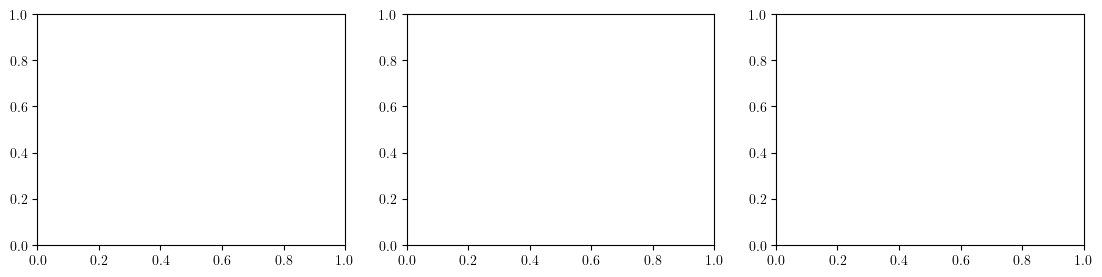

In [3]:
tau_list = ["5e-2"]
color = ["g", "tab:orange", "r"]
title_text = [r"$\tau_{in}^* < \tau_{in, c}^*$", r"$\tau_{in}^* = \tau_{in, c}^*$", r"$\tau_{in}^* > \tau_{in, c}^*$"]
Fd_list = [150]*len(tau_list)
alp_list = [1]*len(tau_list)

begin = 13000
end = 8000
Nevery = 1

fig, ax = plt.subplots(1, 3, figsize = (13.5, 3))

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Fd{fd}".format(fd = Fd_list[i]), "tau_{tau}".format(tau = tau_list[i]), "laneOrder.dat")
    [[step, order], _] = readData(fpath, 1)

    time = [(j-eq_steps)*dt for j in step[begin::Nevery]]
    order = order[begin::Nevery]
    ax[i].plot(time, order, "-", color = color[i], lw = lw, alpha = alp_list[i], label = r"${tau}$".format(tau = float2latex([tau_list[i]])))

for i in range(len(ax)):
    leg = ax[i].legend(title = r"$\tau_{in}^*$", fontsize = 11, frameon = False)
    leg.get_title().set_fontsize("14")
    ax[i].set_xlabel(r"$t/R\sqrt{k_BT_b/m}$", fontsize = 12)
    ax[i].tick_params(axis = "both", which = "major", direction = "in", labelsize = 12)
    ax[i].set_title(title_text[i], fontsize = 18, loc = "center")

ax[0].set(xlim = (2.15e6, 2.35e6), ylim = (0, 1))
ax[0].set_xticks(np.arange(2.15e6, 2.35e6, 4e4))
ax[0].set_yticks(np.arange(0.1, 1.1, 0.1))
ax[0].set_ylabel(r"$\phi_L$", fontsize = 20)

for i in range(1, len(ax)):
    ax[i].set(xlim = (2.145e6, 2.35e6), ylim = (0, 1))
    ax[i].set_xticks(np.arange(2.15e6, 2.35e6, 4e4))
    ax[i].set_yticks(np.arange(0.1, 1.1, 0.1), "")

ax[2].set_xticks(np.arange(2.15e6, 2.36e6, 4e4))
plt.subplots_adjust(wspace = 0.05)

# fig.savefig(os.path.join(figpath, "Fd_100_laneOrder.png"), dpi = 1000, bbox_inches = "tight")

In [ ]:
fig2, ax2 = plt.subplots(1, 3, figsize = (13.5, 3))

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Fd{fd}".format(fd = Fd_list[i]), "tau_{tau}".format(tau = tau_list[i]), "laneOrder.dat")
    [[step, order], _] = readData(fpath, 1)

    # ax2 : distribution of phi
    phi = np.linspace(0, xmax, nBins + 1)
    Bins = np.zeros(nBins + 1)

    for val in order:
        id = m.floor(val/binW)
        Bins[id] += int(1)

    totalCount = sum(Bins)
    
    for j in range(len(Bins)):
        Bins[j] /= (totalCount)

    ax2[i].plot(phi, Bins, "o-", color = color[i], lw = 1, label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    
    ax2[i].tick_params(axis = "both", which = "major", direction = "in", labelsize = 12)
    ax2[i].set(xlim = (0, 1))
    ax2[i].set_xlabel(r"$\phi_L$", fontsize = 18)

    leg = ax2[i].legend(title = r"$\tau_{in}^*$", fontsize = 11)
    leg.get_title().set_fontsize("14")

    ax2[i].set_title(title_text[i], fontsize = 18, loc = "center")

ax2[0].set_ylabel(r"$P(\phi_L)$", fontsize = 18)
ax2[0].set_yticks(np.arange(0, 0.65, 0.15))
ax2[1].set_yticks(np.arange(0, 0.17, 0.04))
ax2[2].set_yticks(np.arange(0, 0.16, 0.04))
plt.subplots_adjust(wspace = 0.18)

# fig2.savefig(os.path.join(figpath, "Fd_100_laneOrderDist.png"), dpi = 1000, bbox_inches = "tight")

In [ ]:
# Compute Standard Error of Mean (SEM) for a data set

fpath = os.path.join(dirpath, "Pe90", "Data39", "laneOrder.dat")
[[step ,order], _] = readData(fpath, 1)
order = order[1:]

tau_run = len(order)
run_avg = sum(order)/tau_run
sample_var = sum([(i - run_avg)**2 for i in order])
sample_var /= (tau_run - 1)

print(tau_run, run_avg, sample_var)

n_blk = []
tau_blk = []

for i in range(2, 5001, 1):
    if(tau_run%i == 0):
        n_blk.append(i)
        tau_blk.append(int(tau_run/i))

tau_blk_inv = [(1/i) for i in tau_blk]
        
print("\nn_blk = ", n_blk, "\ntau_blk = ", tau_blk)

blk_var = []
s = []
for i in range(len(n_blk)):
    blk_avg = np.zeros(n_blk[i])

    for blk in range(n_blk[i]):
        data = order[int(blk*tau_blk[i]):int((blk+1)*tau_blk[i])]
        blk_avg[blk] = sum(data)/len(data)

    total = 0
    for blk in range(n_blk[i]):
        total += (blk_avg[blk] - run_avg)**2

    blk_var.append(total/(n_blk[i]-1))
    s.append(blk_var[i]*tau_blk[i]/sample_var)
    
pos = len(blk_var)-1
print("\nSEM =", m.sqrt(blk_var[pos-1]), m.sqrt(blk_var[pos]))

fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (12, 6)) 
ax1.plot(tau_blk, blk_var, "o-")
ax1.set_xlabel(r"$\tau_{blk}$", fontsize = 15)
ax1.set_ylabel(r"$\sigma^2 (\langle\phi\rangle_{blk})$", fontsize = 15)
# ax1.set_ylim(top = 0.001)

# ax2.plot(tau_blk, s, "o-")
# ax2.set_xlabel(r"$\tau_{blk}$", fontsize = 15)
# ax2.set_ylabel(r"$s(\tau_{blk})$", fontsize = 15)

In [ ]:
# Plot time-averaged lane order parameter and effective temp. plotted with 1 standard deviation
# Last modified : 29.06.25

fs = "full"
ms = 9
mew = 0.7

fpath = os.path.join(dirpath, "Pe90", "avgOrder.dat")
[data, _] = readData(fpath, 1)

nr = data[0]
tau = data[1]
max_val = data[2]
min_val = data[3]
avg = data[4]
std_dev = data[5]

yerr = [[], []]
for i in range(len(nr)):
    yerr[0].append(abs(min_val[i] - avg[i]))
    yerr[1].append(abs(max_val[i] - avg[i]))

fig7, ax7 = plt.subplots(1, 2, figsize = (12, 5))
ax7[0].errorbar(tau, avg, yerr = std_dev, xerr = None, fmt = "-o", ecolor = colors[3], elinewidth = 1, capsize = 5,
             color = colors[3], ms = ms, mec = "k", mew = mew, fillstyle = fs, label = r"$90$")

ax7[0].set_xscale('log')

fpath = os.path.join(dirpath, "Pe90", "avgTemp.dat")
[[nr, tau, avg, sem], _] = readData(fpath, 1)

ax7[1].errorbar(tau, avg, yerr = sem, xerr = None, fmt = "-o", ecolor = colors[3], elinewidth = 1, capsize = 5,
             color = colors[3], ms = ms, mec = "k", mew = mew, fillstyle = fs, label = r"$90$")

ax7[1].set_xscale('log')
ax7[1].set_yscale('log')

ax7[0].set(ylim = (0, 1.01))
ax7[0].set_yticks(np.arange(0, 1.1, 0.1))
ax7[0].set_xlabel(r"$\tau_{in}^*$", fontsize = 20)
ax7[0].set_ylabel(r"$\phi_L$", fontsize = 20)
ax7[0].tick_params(axis='both', which='major', labelsize = 15)
leg = ax7[0].legend(title = r"$F_d^*$", fontsize = 15)
leg.get_title().set_fontsize("15")

ax7[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 20)
ax7[1].set_ylabel(r"$T_{\textrm{eff}}^*~/~T_b$", fontsize = 15)
ax7[1].tick_params(axis='both', which='major', labelsize = 15)
leg = ax7[1].legend(title = r"$F_d^*$", fontsize = 15)
leg.get_title().set_fontsize("15")

plt.subplots_adjust(wspace = 0.3)

# fig7.savefig(os.path.join(figpath, "Phi_gamma_Fd90_bounds_SEM.png"), dpi = 500, bbox_inches = "tight")

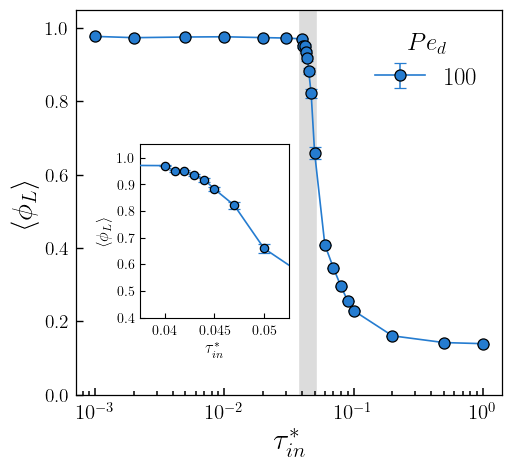

In [18]:
# Plot time-averaged lane order parameter for varying tau_in*
# Last modified : 01.07.25

colors = ["#257cd0ff", "crimson", "olive", "orangered", "#2544D0", "k", "darkorange"]

fs = "full"
ms = 8
mew = 0.9
lw = 1.2

Fd_list = [100]
tau_crit = [4e-2, 5e-2]

fig7, ax7 = plt.subplots(figsize = (5.5, 5))

# ax7.axvline(x = 0.01, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 1)
# ax7.axvline(x = 0.1, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 1)

for i in range(len(Fd_list)):
    fpath = os.path.join(dirpath, "Aug_Nov2025", "Fd{fd}".format(fd = Fd_list[i]), "avgOrder_SEM.dat")
    [data, _] = readData(fpath, 1)

    # for j in range(len(data)):
    #     data[j] = data[j][1:-]
    
    tau = data[1]
    avg_order = data[4]
    std_dev = data[5]
    sem = data[6]

    Stk = [(Fd_list[i]*Tau*Tau) for Tau in tau]

    ax7.errorbar(tau, avg_order, yerr = sem, xerr = None, fmt = "-o", ecolor = colors[i], elinewidth = lw-0.1, capsize = 4, 
                 color = colors[i], mec = "k", mfc = colors[i], ms = ms, lw = lw, mew = mew, fillstyle = "full", 
                 label = r"${pe}$".format(pe = Fd_list[i]), zorder = 2)

    # ax7.axhline(y = avg_order[tau.index(tau_crit[i])], xmin = 0, xmax = 1, ls = "--", color = colors[i], lw = lw)

ax7.set_xscale("log")

ax7.set(ylim = (0, 1.05))
ax7.set_yticks(np.arange(0, 1.01, 0.2))
# ax7.set_xlabel(r"$St$", fontsize = 20)
ax7.set_xlabel(r"$\tau_{in}^*$", fontsize = 22)
ax7.set_ylabel(r"$\langle\phi_L\rangle$", fontsize = 21)
ax7.tick_params(axis = "x", which = "major", direction = "in", length = 5, width = 1.1, pad = 7, labelsize = 15)
ax7.tick_params(axis = "x", which = "minor", direction = "in", length = 2.7, width = 1.1)
ax7.tick_params(axis = "y", which = "major", direction = "in", length = 5, width = 1, pad = 5, labelsize = 14)
leg = ax7.legend(title = r"$Pe_d$", fontsize = 18, loc = "upper right", frameon = False)
leg.get_title().set_fontsize("18")

Rect1 = mpl.patches.Rectangle((3.75e-2, 0), 0.015, 1.05, fc = "gainsboro", ec = "white", zorder = 1)
ax7.add_artist(Rect1)

axin = ax7.inset_axes(bounds = [0.15, 0.2, 0.35, 0.45])
axin.ticklabel_format(style = "sci", axis = 'x', scilimits = (0,0))

axin.errorbar(tau, avg_order, yerr = sem, xerr = None, fmt = "-o", ecolor = colors[i], elinewidth = lw-0.1, capsize = 4, 
                 color = colors[i], mec = "k", mfc = colors[i], ms = ms - 2, lw = lw, mew = mew, fillstyle = "full", zorder = 3)

axin.set_xlabel(r"$\tau_{in}^*$", fontsize = 12)
axin.set_ylabel(r"$\langle\phi_L\rangle$", fontsize = 12)
axin.set(xlim = (3.75e-2, 5.25e-2), ylim = (0.4, 1.05))
axin.set_xticks(np.arange(0.04, 0.055, 0.005))
axin.set_yticks(np.arange(0.4, 1.01, 0.1))
axin.set_xticklabels([r"${word}$".format(word = round(i, 3)) for i in np.arange(0.04, 0.055, 0.005)])
axin.tick_params(axis = "x", which = "major", pad = 5, direction = "in")
axin.tick_params(axis = "x", which = "minor", direction = "in")
axin.tick_params(axis = "y", which = "major", direction = "in")

for spine in ax7.spines.values():
    spine.set_linewidth(0.9)

# fig7.savefig(os.path.join(figpath, "Phi_Fd_100.png"), dpi = 600, bbox_inches = "tight")

In [48]:
# Plot of Max, Min, Avg of the lane order parameter for a constant driving force

fd = 150

ms = 7
lw = 1
colors = ["lightcoral", "cornflowerblue", "yellowgreen"]

fpath = os.path.join(dirpath, "Fd{fd}".format(fd = fd), "avgOrder.dat")
[data, _] = readData(fpath, 1)

tau_in = data[1]
Max = data[2]
Min = data[3]
Avg = data[4]

fig, ax = plt.subplots(figsize = (6, 5))
axin = ax.inset_axes(bounds = [0.125, 0.15, 0.4, 0.4])

# ax.axvline(x = 5e-2, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 0.8)
# ax.axvline(x = 6e-2, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 0.8)

ax.semilogx(tau_in, Max, "o--", color = colors[0], ms = ms, lw = lw, fillstyle = "full", label = r"$(\phi_{L})_{max}$")
ax.semilogx(tau_in, Min, "o--", color = colors[1], ms = ms, lw = lw, fillstyle = "full", label = r"$(\phi_{L})_{min}$")
ax.semilogx(tau_in, Avg, "o-", color = colors[2], ms = ms, lw = lw, fillstyle = "full", label = r"$(\phi_{L})_{avg}$")

axin.axvline(x = 5e-2, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 0.8)
axin.axvline(x = 6e-2, ymin = 0, ymax = 1, ls = "--", color = "k", lw = 0.8)

ms = ms - 2
axin.plot(tau_in, Max, "o--", color = colors[0], ms = ms, lw = lw, fillstyle = "full")
axin.plot(tau_in, Min, "o--", color = colors[1], ms = ms, lw = lw, fillstyle = "full")
axin.plot(tau_in, Avg, "o-", color = colors[2], ms = ms, lw = lw, fillstyle = "full")

# ax.set(xlim = (1e-2, 1e-1))
ax.set(ylim = (0, 1.05))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xlabel(r"$\tau_{in}^*$", fontsize = 20)
ax.set_ylabel(r"$\phi_L$", fontsize = 20)
ax.tick_params(axis = "x", which = "both", direction = "in", labelsize = 14, pad = 8)
ax.tick_params(axis = "y", which = "major", direction = "in", labelsize = 12)
ax.set_title(r"$F_d^* = {fd}$".format(fd = fd), fontsize = 15)

axin.set(xlim = (4e-2, 7.5e-2))
axin.set(ylim = (0, 1.05))
axin.set_xticks(np.arange(4e-2, 7.5e-2, 1e-2), )
axin.set_yticks(np.arange(0, 1.1, 0.2))
axin.set_xlabel(r"$\tau_{in}^*$", fontsize = 13)
axin.set_ylabel(r"$\phi_L$", fontsize = 13)
axin.tick_params(axis = "both", which = "major", direction = "in")
axin.tick_params(axis = "x", which = "major", pad = 6)
axin.ticklabel_format(axis = "both", style = "sci")

leg = ax.legend(fontsize = 15)

# fig.savefig(os.path.join(figpath, "laneOrder_max_min_avg_Fd150.png"), dpi = 600, bbox_inches = "tight")

FileNotFoundError: [Errno 2] No such file or directory: '//media/ashwin/Expansion/ashwin_md/lane/Fd150/avgOrder.dat'

In [ ]:
# Plot the distribution of lane order parameters

Fd = 300
tau_list = ["5e-2", "5.4e-2", "5.5e-2", "6e-2"]

nBins = 50
binW = float(1.0/nBins)
nBins = int(1.0/binW) + 1
print(binW, nBins)

fig, ax = plt.subplots(figsize = (5, 5))
ms = 4
lw = 1

for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Fd{fd}".format(fd = Fd), "tau_{Tau}".format(Tau = tau_list[i]), "laneOrder.dat")
    [data, _] = readData(fpath, 1)

    order = data[1]

    phi = [(j*binW) for j in range(nBins)]
    P_phi = np.zeros(nBins)
    
    for j in range(len(order)):
        P_phi[int(order[j]/binW)] += 1
    
    for j in range(nBins):
        P_phi[j] /= (len(order))

    ax.plot(phi, P_phi, "o-", ms = ms, lw = lw, label = r"${Tau}$".format(Tau = float2latex([tau_list[i]])))

ax.set(xlim = (0, 1), ylim = (-binW, 0.5))
ax.set_xlabel(r"$\phi_L$", fontsize = 18)
ax.set_ylabel(r"$P(\phi_L)$", fontsize = 18)
ax.set_title(r"$F_d^* = {fd}$".format(fd = Fd), fontsize = 15)
leg = ax.legend(title = r"$\tau_{in}^*$", fontsize = 12)
leg.get_title().set_fontsize("16")

# fig.savefig(os.path.join(figpath, "Phi_dist_Fd300.png"), dpi = 500, bbox_inches = "tight")

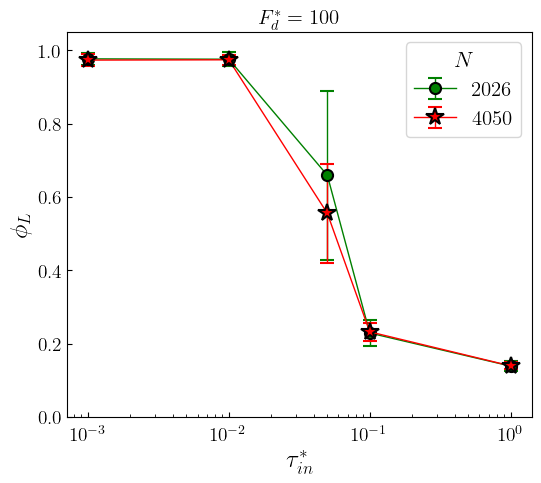

In [5]:
# Studying the system size effects

fig, ax = plt.subplots(figsize = (6, 5))
ms = 8
lw = 1

tau_list = ["1e-3", "1e-2", "5e-2", "1e-1", "1e0"]

fpath = os.path.join(dirpath, "Aug_Oct2025", "Fd100", "avgOrder.dat")
[data, _] = readData(fpath, 1)

tau_in = data[1]
phi_avg = data[4]
phi_std = data[5]

phi_avg_list = []
phi_std_list = []
for i in range(len(tau_list)):
    if(liteval(tau_list[i]) in tau_in):
        phi_avg_list.append(phi_avg[tau_in.index(liteval(tau_list[i]))])
        phi_std_list.append(phi_std[tau_in.index(liteval(tau_list[i]))])

ax.errorbar([liteval(i) for i in tau_list], phi_avg_list, xerr = None, yerr = phi_std_list, marker = "o", color = "g",
            ms = ms, lw = lw, mfc = "g", mec = "k", mew = 1.5, ecolor = "g", elinewidth = 1, capsize = 5, label = "$2026$")

# tau_list = tau_list[0:-1:1]

fpath = os.path.join(dirpath, "size_effects", "N_4050", "Fd100", "avgOrder.dat")
[data, _] = readData(fpath, 1)

tau_in = data[1]
phi_avg = data[4]
phi_std = data[5]

phi_avg_list = []
phi_std_list = []
for i in range(len(tau_list)):
    if(liteval(tau_list[i]) in tau_in):
        phi_avg_list.append(phi_avg[tau_in.index(liteval(tau_list[i]))])
        phi_std_list.append(phi_std[tau_in.index(liteval(tau_list[i]))])

ax.errorbar([liteval(i) for i in tau_list], phi_avg_list, xerr = None, yerr = phi_std_list, marker = "*", color = "r",
            ms = ms + 5, lw = lw, mfc = "r", mec = "k", mew = 1.5, ecolor = "r", elinewidth = 1, capsize = 5, label = r"$4050$")

ax.set_xlabel(r"$\tau_{in}^*$", fontsize = 18)
ax.set_ylabel(r"$\phi_L$", fontsize = 18)
ax.set(ylim = (0, 1.05))
ax.tick_params(axis = "x", which = "both", direction = "in", pad = 7, labelsize = 14)
ax.tick_params(axis = "y", which = "major", direction = "in", labelsize = 14)
ax.set_title(r"$F_d^* = 100$", fontsize = 15)
leg = ax.legend(title = r"$N$", fontsize = 15)
leg.get_title().set_fontsize("16")
ax.set_xscale("log")

# fig.savefig(os.path.join(figpath, "size_effects.png"), dpi = 600, bbox_inches = "tight")

In [ ]:
# Plot of lane order parameter and effective Peclet number vs inertial time

ms = 8
lw = 1.0
mew = 1.0
fs = "none"

Fd_list = [80, 100]
markers = ["o", "o", "s"]
colors = ["crimson", "#2544D0", "olive", "orangered", "#2544D0", "k", "darkorange"]

fig8, ax8 = plt.subplots(figsize = (5, 5))
ax8b = ax8.twinx()

# for i in range(len(Fd_list)):
#     ax8b.axhline(y = Fd_list[i], xmin = 0, xmax = 1, ls = "--", color = colors[i], lw = lw)

points1 = []
points2 = []
for i in range(len(Fd_list)):
    fpath = os.path.join(dirpath, "Fd{Fd}".format(Fd = Fd_list[i]), "avgOrder.dat")

    [data, _] = readData(fpath, 1)
    tau = data[1]
    order = data[4]

    fpath = os.path.join(dirpath, "Fd{Fd}".format(Fd = Fd_list[i]), "avgTemp_x.dat")

    [data, _] = readData(fpath, 1)
    temp = data[4]
    temp_inv = [(1/T) for T in temp]

    Pe = [Fd_list[i]/j for j in temp]

    point1, = ax8.semilogx(tau, order, "-", marker = markers[i], lw = lw, ms = ms, color = colors[i], 
                           label = r"$F_d^* = {Fd}$".format(Fd = Fd_list[i]), mew = mew)
    points1.append(point1)
    
    point2, = ax8b.semilogx(tau, Pe, "-", marker = markers[i], lw = lw, ms = ms, color = colors[i], 
                            label = r"$F_d^* = {Fd}$".format(Fd = Fd_list[i]), mec = colors[i], mew = 1.5, mfc = "white")
    points2.append(point2)
    ax8b.semilogx(tau, Pe, marker = markers[i], lw = lw, ms = ms, color = colors[i], mec = colors[i], mew = 1.5, mfc = "white")

# ax8b.axhline(y = 10, xmin = 0, xmax = 1, ls = "--", color = "k", lw = lw)

ax8.set(ylim = (-0.05, 1.1))
ax8.set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax8.set_ylabel(r"$\phi_L$", fontsize = 15)
ax8.tick_params(axis = "both", which = "major", labelsize = 12)
leg1 = ax8.legend(handles = points1, title = r"$\phi_L$", frameon = True, fontsize = 12, labelspacing = 0.8)
leg1.get_title().set_fontsize("12")

ax8b.set(ylim = (-5, 150))
ax8b.set_ylabel(r"$Pe_{\textrm{eff, x}}$", fontsize = 15)
ax8b.tick_params(axis = "both", which = "major", labelsize = 12)
leg2 = ax8b.legend(handles = points2, title = r"$Pe_{\textrm{eff, x}}$", frameon = True, fontsize = 12, labelspacing = 0.8,
                  bbox_to_anchor = (1, 0.65))
leg2.get_title().set_fontsize("12")

# fig8.savefig(os.path.join(figpath, "Phi_Pe_tau.png"), dpi = 600, bbox_inches = "tight")